# Troubleshooting file encodings in raw data

In [3]:
import sys
from pathlib import Path
#TODO try to remove this somehow
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

Next version supposedly less arbitrary

In [9]:
from pathlib import Path
import pandas as pd

ENCODINGS = ("utf-8", "utf-8-sig", "cp1252")

def diagnose_directory_structural(dir_path, suffix=".csv"):
    report = []

    for path in Path(dir_path).glob(f"*{suffix}"):
        row = {"file": path.name}

        for enc in ENCODINGS:
            try:
                df = pd.read_csv(
                    path,
                    encoding=enc,
                    sep=";",
                    engine="python",
                    on_bad_lines="skip",
                )
            except UnicodeDecodeError:
                continue

            # Structural sanity checks
            row["encoding"] = enc
            row["n_columns"] = len(df.columns)
            row["has_duplicate_columns"] = df.columns.duplicated().any()
            row["dtype_summary"] = df.dtypes.value_counts().to_dict()

            # Check row-wise consistency
            row_lengths = df.notna().sum(axis=1)
            row["min_non_null"] = int(row_lengths.min())
            row["max_non_null"] = int(row_lengths.max())

            row["status"] = "ok"
            break
        else:
            row["status"] = "failed"

        report.append(row)

    return report


In [1]:
report = diagnose_directory_structural(
    "/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/data/raw"
)

for r in report:
    print(r)


NameError: name 'diagnose_directory_structural' is not defined

New one block solution

In [3]:
import pandas as pd
from pathlib import Path

# -------------------------------
# Configuration
# -------------------------------
DATA_DIR = Path("/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/data/raw")
REFERENCE_FILE = DATA_DIR / "IHOPE26_LN_InstanSeq_RAW_RESULTS.csv"
ENCODINGS = ("utf-8", "utf-8-sig", "cp1252")

# -------------------------------
# Reader: preserves old behavior, adds encoding fallback
# -------------------------------
def read_csv_robust(path: Path) -> pd.DataFrame:
    last_error = None
    for enc in ENCODINGS:
        try:
            df = pd.read_csv(
                path,
                encoding=enc,
                sep=None,          # same behavior as your old script
                engine="python",
            )
            print(f"[OK] {path.name} loaded with encoding={enc}")
            return df
        except UnicodeDecodeError as e:
            last_error = e
    raise RuntimeError(f"{path.name}: could not be decoded") from last_error

# -------------------------------
# Load reference schema (ground truth)
# -------------------------------
ref_df = read_csv_robust(REFERENCE_FILE)
REFERENCE_COLUMNS = list(ref_df.columns)

print(f"\nReference schema loaded ({len(REFERENCE_COLUMNS)} columns)\n")

# -------------------------------
# Validation: enforce identical structure
# -------------------------------
def validate_against_reference(df: pd.DataFrame, path: Path):
    if list(df.columns) != REFERENCE_COLUMNS:
        raise ValueError(
            f"{path.name}: column mismatch vs reference"
        )

# -------------------------------
# Test all files in directory
# -------------------------------
for csv_path in sorted(DATA_DIR.glob("*.csv")):
    df = read_csv_robust(csv_path)
    validate_against_reference(df, csv_path)

print("\nAll CSV files load successfully and match the reference schema.")


[OK] IHOPE26_LN_InstanSeq_RAW_RESULTS.csv loaded with encoding=cp1252

Reference schema loaded (782 columns)

[OK] IHOPE20_LN_RAW_RESULTS.csv loaded with encoding=utf-8


ValueError: IHOPE20_LN_RAW_RESULTS.csv: column mismatch vs reference

version that doesnt crash at once

In [1]:
import pandas as pd
from pathlib import Path

# -------------------------------
# Configuration
# -------------------------------
DATA_DIR = Path("/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/data/raw")
REFERENCE_FILE = DATA_DIR / "IHOPE26_LN_InstanSeq_RAW_RESULTS.csv"
ENCODINGS = ("utf-8", "utf-8-sig", "cp1252")

# -------------------------------
# Header-only reader with encoding fallback
# -------------------------------
def read_csv_header(path: Path) -> list[str]:
    last_error = None

    for enc in ENCODINGS:
        try:
            df = pd.read_csv(
                path,
                encoding=enc,
                sep=None,          # preserve old behavior
                engine="python",
                nrows=0,           # header only (fast)
            )
            print(f"[OK] {path.name} (encoding={enc}, cols={len(df.columns)})")
            return list(df.columns)
        except UnicodeDecodeError as e:
            last_error = e

    raise RuntimeError(f"{path.name}: could not decode header") from last_error

# -------------------------------
# Load reference header
# -------------------------------
ref_cols = read_csv_header(REFERENCE_FILE)
ref_col_set = set(ref_cols)

print(f"\nReference loaded: {REFERENCE_FILE.name}")
print(f"Reference column count: {len(ref_cols)}\n")

# -------------------------------
# Audit all files (header-only, non-crashing)
# -------------------------------
for csv_path in sorted(DATA_DIR.glob("*.csv")):
    print(f"\n--- Auditing {csv_path.name} ---")

    try:
        cols = read_csv_header(csv_path)
    except Exception as e:
        print(f"FAILED TO READ HEADER: {e}")
        continue

    col_set = set(cols)

    missing = ref_col_set - col_set
    extra = col_set - ref_col_set
    order_mismatch = cols != ref_cols

    if not missing and not extra and not order_mismatch:
        print("Columns identical to reference")
        continue

    if missing:
        print(f"Missing columns ({len(missing)}):")
        for c in sorted(missing):
            print(f"  - {c}")

    if extra:
        print(f"Extra columns ({len(extra)}):")
        for c in sorted(extra):
            print(f"  + {c}")

    if order_mismatch and not missing and not extra:
        print("Column order differs from reference")


[OK] IHOPE26_LN_InstanSeq_RAW_RESULTS.csv (encoding=cp1252, cols=782)

Reference loaded: IHOPE26_LN_InstanSeq_RAW_RESULTS.csv
Reference column count: 782


--- Auditing IHOPE20_LN_RAW_RESULTS.csv ---
[OK] IHOPE20_LN_RAW_RESULTS.csv (encoding=utf-8, cols=782)
Missing columns (1):
  - Image
Extra columns (1):
  + ﻿Image

--- Auditing IHOPE20_Spleen_RAW_RESULTS_2.csv ---
[OK] IHOPE20_Spleen_RAW_RESULTS_2.csv (encoding=utf-8, cols=782)
Missing columns (1):
  - Image
Extra columns (1):
  + ﻿Image

--- Auditing IHOPE26_LN_InstanSeq.csv ---
[OK] IHOPE26_LN_InstanSeq.csv (encoding=cp1252, cols=782)
Columns identical to reference

--- Auditing IHOPE26_LN_InstanSeq_RAW_RESULTS.csv ---
[OK] IHOPE26_LN_InstanSeq_RAW_RESULTS.csv (encoding=cp1252, cols=782)
Columns identical to reference

--- Auditing IHOPE26_Spleen_InstanSeq_RAW_RESULTS.csv ---
[OK] IHOPE26_Spleen_InstanSeq_RAW_RESULTS.csv (encoding=utf-8, cols=782)
Columns identical to reference

--- Auditing IHOPE27_LN_InstanSeq_RAW_RESULTS.csv -

In [ ]:
aaand a test

In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/data/raw")
ENCODINGS = ("utf-8", "cp1252")

def clean_cell_columns_in_memory(path: Path) -> pd.DataFrame:
    # read
    for enc in ENCODINGS:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc)
            used_encoding = enc
            break
        except UnicodeDecodeError:
            continue
    else:
        raise RuntimeError(f"Could not decode {path}")

    # normalize columns
    df.columns = df.columns.str.strip().str.lstrip("\ufeff")

    # drop unwanted
    df = df.drop(columns=[c for c in ['Image', 'Name', 'Classification'] if c in df.columns])

    # strip Cell:
    df.columns = df.columns.str.replace(r'^Cell:\s*', '', regex=True)

    return df, used_encoding

# ---------------------------
# Run test
# ---------------------------
results = {}

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    df, enc = clean_cell_columns_in_memory(csv_path)

    results[csv_path.name] = {
        "encoding": enc,
        "n_cols": len(df.columns),
        "has_micro": any("µ" in c or "\xb5" in c for c in df.columns),
        "example_micro_cols": [c for c in df.columns if "µ" in c or "\xb5" in c][:5],
    }

# Print summary
for fname, info in results.items():
    print(f"\n{fname}")
    for k, v in info.items():
        print(f"  {k}: {v}")


In [ ]:
from pathlib import Path

for csv_path in Path(DATA_DIR).glob("*.csv"):
    df, _ = clean_cell_columns_in_memory(csv_path)
    bad = [c for c in df.columns if " um" in c or "u m" in c]
    if bad:
        print(csv_path.name, bad[:5])


version that normalizes micro

In [ ]:
import pandas as pd

def _clean_cell_columns_df(path, encoding="utf-8"):
    # Read with encoding fallback
    try:
        df = pd.read_csv(path, sep=None, engine="python", encoding=encoding)
    except UnicodeDecodeError:
        df = pd.read_csv(path, sep=None, engine="python", encoding="cp1252")

    # Normalize column names
    df.columns = (
        df.columns
          .str.strip()
          .str.lstrip("\ufeff")                      # remove BOM
          .str.replace(r'\bum\^2\b', 'µm^2', regex=True)
          .str.replace(r'\bum\b', 'µm', regex=True)  # normalize micro units
    )

    # Drop unused columns
    df = df.drop(columns=[c for c in ['Image', 'Name', 'Classification'] if c in df.columns])

    # Remove Cell: prefix
    df.columns = df.columns.str.replace(r'^Cell:\s*', '', regex=True)

    return df


In [ ]:
def clean_cell_columns(input_csv_path, output_csv_path, encoding="utf-8"):
    df = _clean_cell_columns_df(input_csv_path, encoding)
    df.to_csv(output_csv_path, index=False, encoding="utf-8")


In [ ]:
from pathlib import Path

DATA_DIR = Path("/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/data/raw")

reference_cols = None

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    df = _clean_cell_columns_df(csv_path)

    # 1. Check that no Excel-damaged micro units remain
    bad_micro = [c for c in df.columns if " um" in c or c.endswith("um") or "um^2" in c]
    if bad_micro:
        print(f"{csv_path.name}: BAD micro units:", bad_micro[:5])

    # 2. Check schema consistency
    if reference_cols is None:
        reference_cols = list(df.columns)
    elif list(df.columns) != reference_cols:
        print(f"{csv_path.name}: COLUMN MISMATCH vs reference")


A snippet to just test delimiter and col names

In [1]:
import pandas as pd

def sanity_check_csv(path, encoding="utf-8"):
    print(f"--- Sanity check for {path} ---")
    try:
        df = pd.read_csv(path, sep=None, engine='python', encoding=encoding)
    except UnicodeDecodeError:
        print("Fallback to cp1252 encoding")
        df = pd.read_csv(path, sep=None, engine='python', encoding="cp1252")

    # Check delimiter detection
    print("Number of columns detected:", len(df.columns))

    # Peek at column names
    print("First 15 columns:", df.columns[:15].tolist())

    # Peek at the data
    print("Head of the dataframe:\n", df.head(3))

    return df

# Example usage:
good_df = sanity_check_csv("../data/raw/IHOPE26_LN_InstanSeq.csv")
bad_df  = sanity_check_csv("../data/raw/IHOPE26_Spleen_InstanSeq_RAW_RESULTS.csv")


--- Sanity check for ../data/raw/IHOPE26_LN_InstanSeq.csv ---
Fallback to cp1252 encoding
Number of columns detected: 782
First 15 columns: ['Image', 'Object ID', 'Object type', 'Name', 'Classification', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Cell: Area µm^2', 'Cell: Length µm', 'Cell: Circularity', 'Cell: Solidity', 'Cell: Max diameter µm', 'Cell: Min diameter µm']
Head of the dataframe:
                                      Image  \
0  IHOPE26 FULL _ testing new segmentation   
1  IHOPE26 FULL _ testing new segmentation   
2  IHOPE26 FULL _ testing new segmentation   

                              Object ID Object type  Name  Classification  \
0  c39d2229-52e1-4b70-a8a8-55486b8d7b77        Cell   NaN             NaN   
1  9aa91f74-8d97-4331-a7df-6fd37e8560a1        Cell   NaN             NaN   
2  71e5c938-d604-4de5-8f9c-c887b780f1a6        Cell   NaN             NaN   

       Parent      ROI  Centroid X µm  Centroid Y µm  Cell: Area µm^2  ...  \
0  Annotation  Polygon

with new sxript

In [9]:
import importlib
from scripts import preprocessing  # whatever the filename is

importlib.reload(preprocessing)


<module 'scripts.preprocessing' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/preprocessing.py'>

In [10]:
good_raw = "../data/raw/IHOPE26_LN_InstanSeq.csv"
bad_raw  = "../data/raw/IHOPE26_Spleen_InstanSeq_RAW_RESULTS.csv"

good_clean = "../data/clean/IHOPE26_LN_clean.csv"
bad_clean  = "../data/clean/IHOPE26_Spleen_clean.csv"

preprocessing.clean_cell_columns(good_raw, good_clean)
preprocessing.clean_cell_columns(bad_raw, bad_clean)


Failed to read ../data/raw/IHOPE26_LN_InstanSeq.csv as utf-8, trying cp1252...
Cleaned CSV saved to: ../data/clean/IHOPE26_LN_clean.csv
Cleaned CSV saved to: ../data/clean/IHOPE26_Spleen_clean.csv


In [11]:
import pandas as pd

def sanity_check_csv(path, n_cols=15):
    print(f"\n--- Sanity check for {path} ---")
    df = pd.read_csv(path, encoding="utf-8")
    print("Number of columns:", df.shape[1])
    print("First columns:", df.columns[:n_cols].tolist())
    print("Head:")
    display(df.head(3))


In [12]:
sanity_check_csv(good_clean)
sanity_check_csv(bad_clean)



--- Sanity check for ../data/clean/IHOPE26_LN_clean.csv ---
Number of columns: 779
First columns: ['Object ID', 'Object type', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Length µm', 'Circularity', 'Solidity', 'Max diameter µm', 'Min diameter µm', 'Nucleus: DAPI: Mean', 'Nucleus: DAPI: Median', 'Nucleus: DAPI: Min']
Head:


,Object ID,Object type,Parent,ROI,Centroid X µm,Centroid Y µm,Area µm^2,Length µm,Circularity,Solidity,...,CD68: Min,CD68: Max,CD68: Std.Dev.,Nucleus: Area µm^2,Nucleus: Length µm,Nucleus: Circularity,Nucleus: Solidity,Nucleus: Max diameter µm,Nucleus: Min diameter µm,Nucleus/Cell area ratio
0,c39d2229-52e1-4b70-a8a8-55486b8d7b77,Cell,Annotation,Polygon,5064.0,14777.7,14.0056,16.0039,0.6872,0.9489,...,0,2,0.5741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9aa91f74-8d97-4331-a7df-6fd37e8560a1,Cell,Annotation,Polygon,5087.6,14784.1,28.5032,24.0039,0.6216,0.9381,...,1,10,2.1957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,71e5c938-d604-4de5-8f9c-c887b780f1a6,Cell,Annotation,Polygon,5138.8,15305.5,115.6042,49.2773,0.5983,0.9491,...,0,3,0.5675,97.3228,46.2891,0.5708,0.9429,13.0186,10.6455,0.8419



--- Sanity check for ../data/clean/IHOPE26_Spleen_clean.csv ---
Number of columns: 779
First columns: ['Object ID', 'Object type', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Length µm', 'Circularity', 'Solidity', 'Max diameter µm', 'Min diameter µm', 'Nucleus: DAPI: Mean', 'Nucleus: DAPI: Median', 'Nucleus: DAPI: Min']
Head:


,Object ID,Object type,Parent,ROI,Centroid X µm,Centroid Y µm,Area µm^2,Length µm,Circularity,Solidity,...,CD68: Min,CD68: Max,CD68: Std.Dev.,Nucleus: Area µm^2,Nucleus: Length µm,Nucleus: Circularity,Nucleus: Solidity,Nucleus: Max diameter µm,Nucleus: Min diameter µm,Nucleus/Cell area ratio
0,8e4696c9-7e1e-4bd5-bb7b-952adcf1a14b,Cell,Annotation,Polygon,507.33,2195.3,11.0104,15.0112,0.6140,0.9163,...,1.0,3.0,0.5532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b50a20da-8487-47e7-9f0a-4673f721f0ec,Cell,Annotation,Polygon,611.12,2393.0,72.3929,46.7145,0.4169,0.8987,...,1.0,4.0,0.5691,68.8832,46.7145,0.3967,0.8809,16.0019,6.1987,0.9515
2,0512f1df-77f4-48de-82b2-0609b67f0a7d,Cell,Annotation,Polygon,596.71,2397.0,60.9254,45.2867,0.3733,0.8847,...,0.0,5.0,0.7455,58.9664,44.2941,0.3777,0.8822,14.2802,5.8087,0.9678


In [13]:
def check_micro_variants(path):
    df = pd.read_csv(path, encoding="utf-8")
    bad_cols = [c for c in df.columns if "Â" in c or "um" in c]
    print(f"{path}")
    print("Suspicious columns:", bad_cols[:10])


In [14]:
check_micro_variants(good_clean)
check_micro_variants(bad_clean)


../data/clean/IHOPE26_LN_clean.csv
Suspicious columns: []
../data/clean/IHOPE26_Spleen_clean.csv
Suspicious columns: []


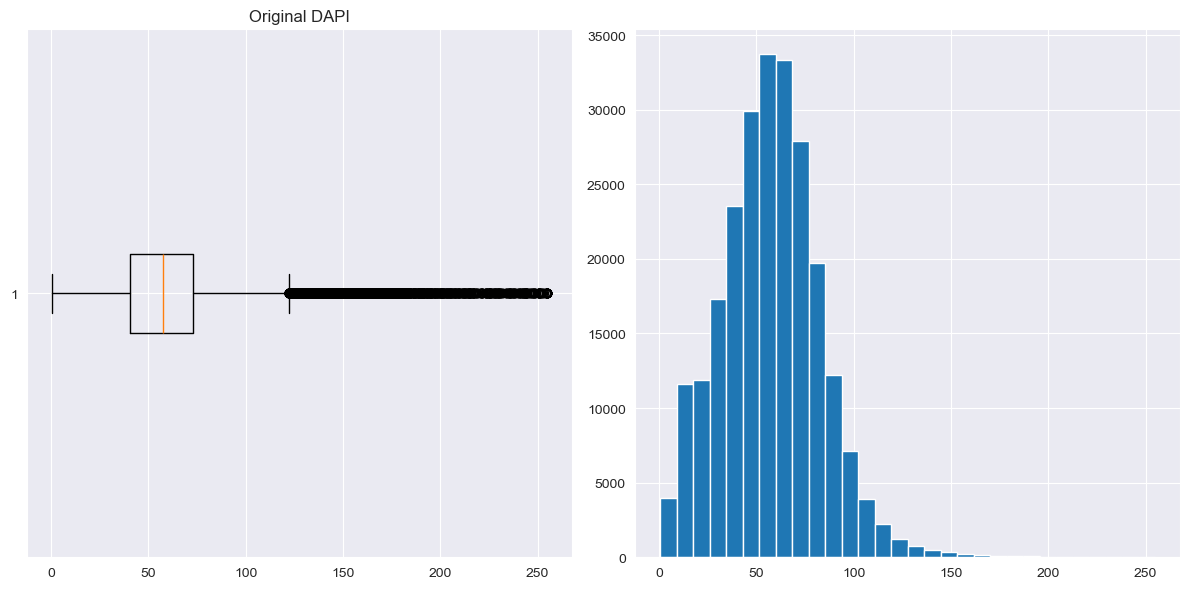

Filtered data saved to: ../data/processed/IHOPE26_LN_filtered.csv


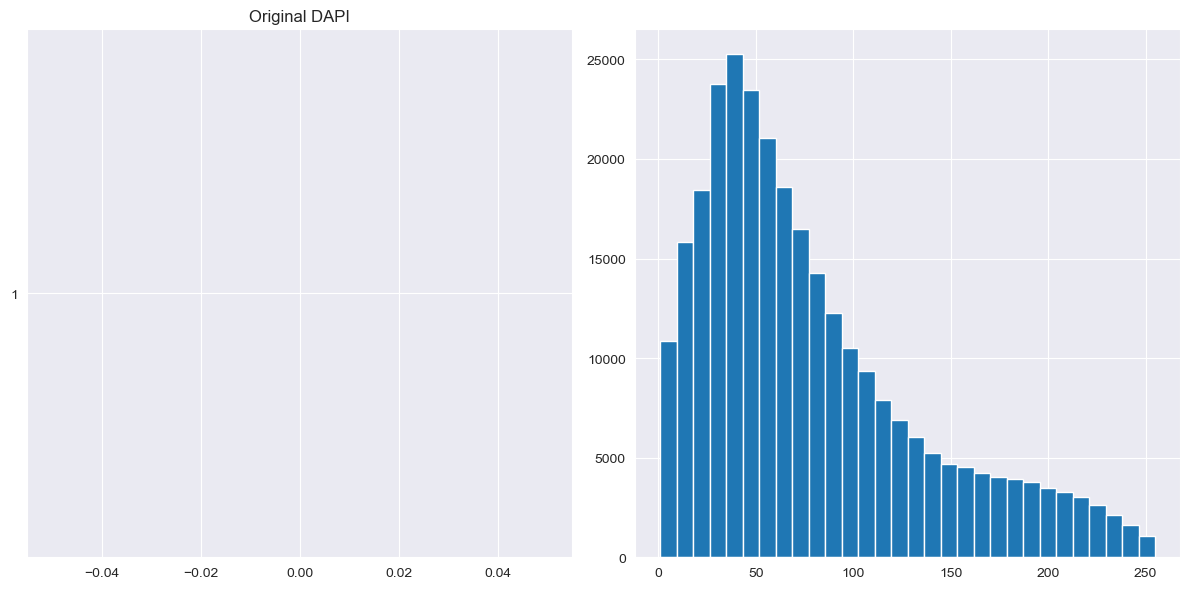

Filtered data saved to: ../data/processed/IHOPE26_Spleen_filtered.csv


In [15]:
preprocessing.preprocess(
    input_file=good_clean,
    output_file="../data/processed/IHOPE26_LN_filtered.csv",
    plot=True
)

preprocessing.preprocess(
    input_file=bad_clean,
    output_file="../data/processed/IHOPE26_Spleen_filtered.csv",
    plot=True
)


In [19]:
import pandas as pd

spleen_clean = "../data/processed/IHOPE26_Spleen_filtered.csv"
df = pd.read_csv(spleen_clean)

print(df.shape)
print(df.columns.tolist()[:20])


(274666, 779)
['Object ID', 'Object type', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Length µm', 'Circularity', 'Solidity', 'Max diameter µm', 'Min diameter µm', 'Nucleus: DAPI: Mean', 'Nucleus: DAPI: Median', 'Nucleus: DAPI: Min', 'Nucleus: DAPI: Max', 'Nucleus: DAPI: Std.Dev.', 'Nucleus: Ki67: Mean', 'Nucleus: Ki67: Median', 'Nucleus: Ki67: Min']


In [20]:
[d for d in df.columns if "DAPI" in d]


['Nucleus: DAPI: Mean',
 'Nucleus: DAPI: Median',
 'Nucleus: DAPI: Min',
 'Nucleus: DAPI: Max',
 'Nucleus: DAPI: Std.Dev.',
 'Cytoplasm: DAPI: Mean',
 'Cytoplasm: DAPI: Median',
 'Cytoplasm: DAPI: Min',
 'Cytoplasm: DAPI: Max',
 'Cytoplasm: DAPI: Std.Dev.',
 'Membrane: DAPI: Mean',
 'Membrane: DAPI: Median',
 'Membrane: DAPI: Min',
 'Membrane: DAPI: Max',
 'Membrane: DAPI: Std.Dev.',
 'DAPI: Mean',
 'DAPI: Median',
 'DAPI: Min',
 'DAPI: Max',
 'DAPI: Std.Dev.']

In [21]:
dapi = df["DAPI: Mean"]  # adjust if needed

print("Total rows:", len(df))
print("Non-NaN DAPI:", dapi.notna().sum())
print("Unique DAPI values:", dapi.nunique())

print(dapi.describe())


Total rows: 274666
Non-NaN DAPI: 274666
Unique DAPI values: 245354
count    274666.000000
mean         77.430384
std          54.560837
min           5.165900
25%          36.437700
50%          62.469450
75%         105.452500
max         236.893900
Name: DAPI: Mean, dtype: float64


In [22]:
area = df["Area µm^2"]

filtered = df[(area >= 20) & (area <= 200)]

print("After area filter:", filtered.shape)
print("Non-NaN DAPI after area filter:", filtered["DAPI: Mean"].notna().sum())
print("Unique DAPI after area filter:", filtered["DAPI: Mean"].nunique())


After area filter: (274666, 779)
Non-NaN DAPI after area filter: 274666
Unique DAPI after area filter: 245354


In [23]:
good_df = pd.read_csv(good_clean)
bad_df  = pd.read_csv(bad_clean)

print("Column sets identical:",
      set(good_df.columns) == set(bad_df.columns))


Column sets identical: True
